# Singular vector transformation (SVT)
The novel SVD-based interface reduction approach is embedded in `pyFBS`. For more details on the singular vector transformation, refer to the documentation.

In [1]:
import pyfbs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Numerical example
First, load a predefined datasets from the example directory. 

In [2]:
pyfbs.io.download_lab_testbench()

100%|██████████| 10/10 [00:00<00:00, 30196.57it/s]


100%|██████████| 3/3 [00:00<00:00, 12421.43it/s]


100%|██████████| 10/10 [00:00<00:00, 27906.21it/s]


In [3]:
stl = r"./lab_testbench/STL/B.stl"
xlsx_pos = r"./lab_testbench/Measurements/ammeasurements.xlsx"

full_file = r"./lab_testbench/FEM/B.full"
ress_file = r"./lab_testbench/FEM/B.rst"

#### MK model
Prepare a MK model for the FRF synthetization. For more details check-out the *03_FRF_synthetization.ipynb* example. 

In [4]:
MK = pyfbs.mck.Model.from_ansys(ress_file,full_file,no_modes = 100,recalculate = False, mesh_scale=1000)

C:\Users\OliverZobel\Documents\pyFBS\pyFBS\mck\mck.py:534: ResourceWarning: unclosed file <_io.BufferedReader name='./lab_testbench/FEM/B.full.pkl'>
  _m, _k, _angular_eig_freq, _eig_val, _eig_vec, _no_modes = pickle.load(
C:\Users\OliverZobel\Documents\pyFBS\pyFBS\mck\mck.py:188: ResourceWarning: unclosed file <_io.BufferedReader name='./lab_testbench/FEM/B.full.pkl'>
  pickle.load(open(p_file, "rb"))


Add the STL and the corresponding mesh from FEM to the 3D view:

In [5]:
view3D = pyfbs.display.View3D(show_origin= True)
mesh = view3D.add_stl(stl,name = "engine_mount",color = "#8FB1CC",opacity = .1)
view3D.add_mesh(MK.mesh, name="mesh", cmap="coolwarm", show_edges=True, show_scalar_bar=False);

C:\Users\OliverZobel\Documents\pyFBS\pyFBS\display\display.py:559: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  _mesh = mesh.extract_surface()


To evaluate the FEM model the mode shapes can be animated: 

In [6]:
select_mode = 6
_modeshape = MK.get_modeshape(select_mode)

view3D.add_modeshape(_modeshape, mesh_or_name="mesh", run_animation=True)

The mode shape deformation can also be cleared from the display:

In [7]:
view3D.clear_modeshape()

Load the channel and datasets.

In [8]:
df_imp = pd.read_excel(xlsx_pos, sheet_name='Impacts_B')
df_chn = pd.read_excel(xlsx_pos, sheet_name='Channels_B')

#view3D.show_imp(df_imp)
#view3D.show_chn(df_chn)

Currently only "snap-to-node" FRF synthetization is supported. Therefore, the locations of the channels and impacts have to updated to snap to the nearest node from FEM model.

In [9]:
df_chn_up = MK.update_locations_df(df_chn)
df_imp_up = MK.update_locations_df(df_imp)

#view3D.show_chn(df_chn_up, color = "k",overwrite = False)
#view3D.show_imp(df_imp_up, color = "k",overwrite = False)

#### FRF synthetization
Finally, the FRFs synthetization at the channel/impact DoFs:

In [10]:
MK.frf_synth(df_chn_up,df_imp_up,f_start = 0,modal_damping = 0.003,frf_type = "accelerance")

## Singular vector transformation 
For the SVT to be applied, input ``df_imp_up`` and output channel ``df_chn_up`` informations must be selected. The grouping number ``grouping_no`` must be carefully assigned to the DoFs involved in the transformation process. This is pre-defined by the user when building the excel file for the design of experiments and successively imported in the channels (ref. channels) structure pandas.DataFrame under the label `` Grouping``. The SVT reduction matrices are then extracted by applying a truncated SVD on the chosen measured FRF datasets ``FRF``. Here, a number of 6 singular components (``no_svs``) is chosen along the whole frequency range of interest ``freq``. Take care of the requirements of the SVT when applied within a FBS decoupling application (see *FBS_decoupling_SVT.ipynb*). 

In [11]:
k = 6
svt = pyfbs.interface.SVT(df_chn_up,df_imp_up, freq = MK.freq, frf = MK.frf, grouping_no = [1,10],no_svs = k)


Show the CMIF plot and highlight the chosen singular values per frequency line

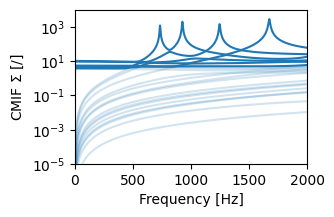

In [12]:
plt.figure(figsize = (3,2))

plt.semilogy(svt.s[:,:k],color = "tab:blue")
plt.semilogy(svt.s[:,k:],"tab:blue",alpha = 0.2)
plt.xlim(0,2000)
plt.ylim(1e-5,1e4)

plt.xlabel("Frequency [Hz]");
plt.ylabel(r"CMIF $\Sigma$ [/]");

For the sake of the example, the transformation is applied here only on one subsystem ``FRF``. 

In [13]:
_,_,FRF_sv= svt.apply_svt(df_chn_up,df_imp_up, freq = MK.freq,frf = MK.frf)


Display the transformed FRFs. Note that since we have transformed the FRF datasets that was used for the extraction of the reduced singular bases, the resulting FRF matrix will be the corresponding matrix of singular values. In the following, the first 2 diagonal element of the matrix are plotted along the frequency axis.

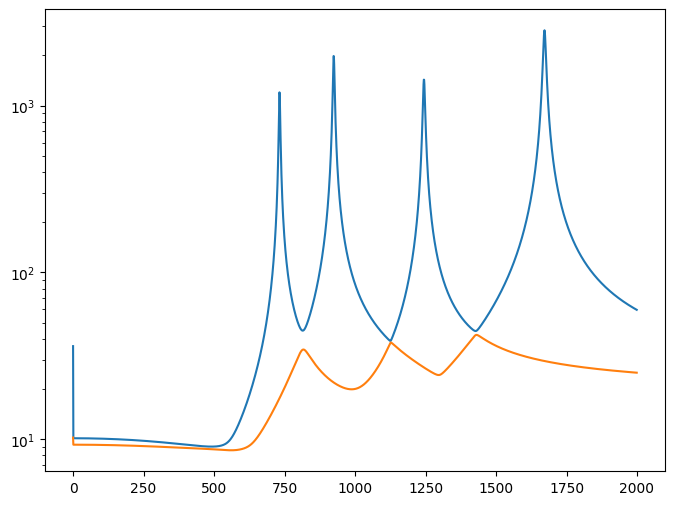

In [14]:
select_out = 0
select_in = 0

plt.figure(figsize = (8,6))
plt.semilogy(svt.freq,np.abs(FRF_sv[:,select_out,select_in]))
plt.semilogy(svt.freq,np.abs(FRF_sv[:,select_out+1,select_in+1]))

#### Consistency of the SVT

Check comparison of the measured FRFs with the SVT-filtered (reduced and back-transformed) ones.

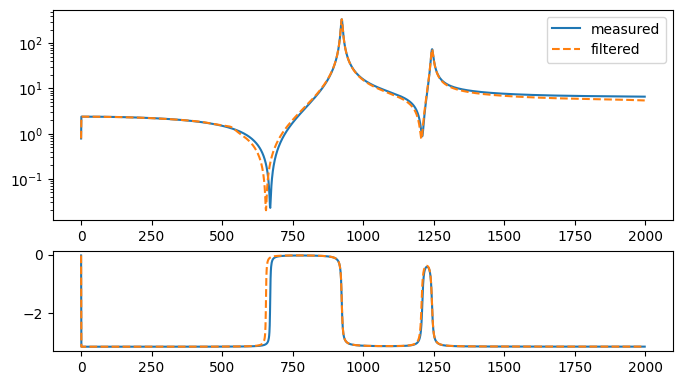

In [15]:
select_out = 2
select_in = 2

FRF_filt=np.zeros_like(svt.frf,dtype = complex)
for i in np.arange(len(svt.freq)):
    FRF_filt[i,:,:]=svt.fu[i,:,:] @ svt.frf[i,:,:]@ svt.ff[i,:,:]
        
plt.figure(figsize = (8,6))
plt.subplot(211)
plt.semilogy(svt.freq,np.abs(svt.frf[:,select_out,select_in]),label = "measured")
plt.semilogy(svt.freq,np.abs(FRF_filt[:,select_out,select_in]),'--',label = "filtered")
plt.legend()

plt.subplot(413)
plt.plot(svt.freq,np.angle(svt.frf[:,select_out,select_in]),label = "measured")
plt.plot(svt.freq,np.angle(FRF_filt[:,select_out,select_in]),'--',label = "filtered")